# Práctica 5 – Inteligencia Artificial Explicable (XAI)

**Asignatura:** Inteligencia Artificial  
**Tema:** Explainable AI sobre perceptrón multicapa (configuración A)  
**Nombres:** Gissela  Tasiguano  y Ariel Gómez


## PARTE OPCIONAL

Implementa explainers sobre un problema de clasificación de imágenes. Vamos a partir de la parte B de la práctica 3 sobre una de las configuraciones del CNN que desarrollasteis sobre el dataset Fashion-MNIST. Implementa al menos 2 explainers de los siguientes:

Grad-CAM (https://pypi.org/project/grad-cam/),

Integrated Gradients (https://github.com/ankurtaly/Integrated-Gradients),

Anchors (https://github.com/marcotcr/anchor)

LIME (https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20images%20-%20Pytorch.ipynb)

SHAP (https://shap.readthedocs.io/en/latest/image_examples.html)

Analiza, compara y discute los resultados obtenidos.

In [78]:
#Importación de librerías necesario

import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

#DEFINIR TRANSFORMACION
#Convertir a tensor y normalizar. Como es escala de grises (1 canal), usamos una sola media y desviación

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
 
#CARGAR EL DATASET

# Definir batch_size (se cambiará según la configuración)

batch_size_2 = 128   # Configuración 2

# Cargar el dataset de entrenamiento

# root='./data' → carpeta donde se guardan los datos
# train=True → carga el conjunto de entrenamiento
# download=True → descarga si no existe
# transform=transform → aplica las transformaciones definidas arriba

trainset2 = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Crear el DataLoader de entrenamiento
# shuffle=True → mezcla los datos en cada epoch (muy importante)
# num_workers=2 → usa 2 hilos para cargar datos (opcional)

trainloader2 = DataLoader(
    trainset2,
    batch_size=batch_size_2,
    shuffle=True,
    num_workers=2
)

# Cargar el dataset de test

testset2 = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Crear el DataLoader de test
# shuffle=False → no hace falta mezclar los datos de test

testloader2 = DataLoader(
    testset2,
    batch_size=batch_size_2,
    shuffle=False,
    num_workers=2
)

# Nombres de las clases

classes = (
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
)

## Definir la red CNN Configuración 

In [79]:
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()

        # CAPA CONVOLUCIONAL 1
        # Entrada: 1 canal (grayscale)
        # Salida: 32 filtros (más filtros que Config 1)
        # kernel_size = 5x5 (más grande que Config 1 → 3x3)
        # Este kernel más grande permite capturar patrones más amplios.
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)

        # PRIMERA CAPA DE POOLING
        # MaxPool 2x2 (igual tamaño que Config 1)
        # Reduce la imagen a la mitad en cada dimensión.
        self.pool1 = nn.MaxPool2d(2, 2)

        # CAPA CONVOLUCIONAL 2
        # Entrada: 32 filtros
        # Salida: 64 filtros (igual que Config 1)
        # kernel_size = 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # SEGUNDA CAPA DE POOLING
        # Configuración 2 usa DOS poolings (Config 1 solo usa uno)
        self.pool2 = nn.MaxPool2d(2, 2)

        # CAPA CONVOLUCIONAL 3
        # Entrada: 64 filtros
        # Salida: 128 filtros (más filtros que Config 1)
        # kernel_size = 3x3
        # Esta capa adicional permite extraer características más complejas.
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

        # CAPAS DENSAS (CONECTADAS)
        # Después de conv/pool, el tamaño final es 128 * 3 * 3
        # Primera capa densa oculta con 256 neuronas
        # (más neuronas que Config 1 → 128)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)

        # Segunda capa densa oculta con 128 neuronas
        # (Config 1 no tenía segunda capa densa)
        self.fc2 = nn.Linear(256, 128)

        # Capa de salida con 10 neuronas (10 clases de Fashion-MNIST)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv1 + ReLU + Pool1
        x = self.pool1(F.relu(self.conv1(x)))

        # Conv2 + ReLU + Pool2
        x = self.pool2(F.relu(self.conv2(x)))

        # Conv3 + ReLU (sin pooling)
        x = F.relu(self.conv3(x))

        # Aplanar para pasar a capas densas
        x = x.reshape(-1, 128 * 3 * 3)

        # Capa densa 1 + ReLU
        x = F.relu(self.fc1(x))

        # Capa densa 2 + ReLU
        x = F.relu(self.fc2(x))

        # Capa de salida (sin softmax, CrossEntropyLoss lo aplica internamente)
        x = self.fc3(x)

        return x

## DEFINIR EL OPTIMIZADOR

Epoch 1/12 - Loss: 0.6517
Epoch 2/12 - Loss: 0.3953
Epoch 3/12 - Loss: 0.3343
Epoch 4/12 - Loss: 0.2953
Epoch 5/12 - Loss: 0.2670
Epoch 6/12 - Loss: 0.2462
Epoch 7/12 - Loss: 0.2263
Epoch 8/12 - Loss: 0.2115
Epoch 9/12 - Loss: 0.1965
Epoch 10/12 - Loss: 0.1842
Epoch 11/12 - Loss: 0.1698
Epoch 12/12 - Loss: 0.1565
Accuracy total Configuración 2: 0.9105


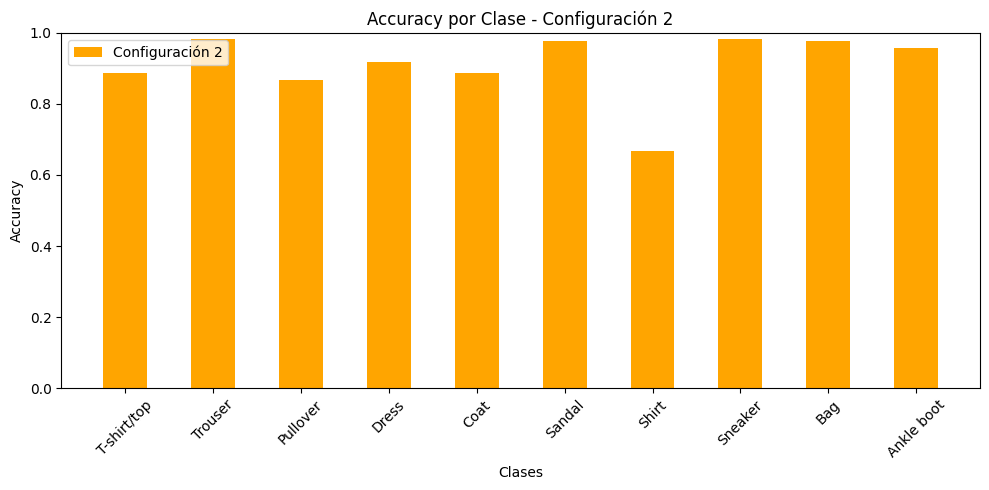

In [80]:
#Definir el optimizador
model2 = CNN2()
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.0005) #Learning rate

#Entrenar la red
def train(model, loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:#Aquí entra el batch_size, cada iteración procesa un batch de imágenes
            optimizer.zero_grad()# REinicia los gradientes antes de cada batch
            outputs = model(images)#Forward pass->el modelo hace predicciones
            loss = criterion(outputs, labels)#Calcula la pérdida
            loss.backward()#Calcula gradientes
            optimizer.step()#Actuliza pesos usando el optimizador aquí inteviene el learning rate
            running_loss += loss.item()#Acumula la pérdida para mostrar al final del epoch

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(loader):.4f}")

train(model2, trainloader2, criterion, optimizer2, epochs=12) #Epochs

#Evaluar accurancy total
def evaluate(model, loader):
    correct = 0 #Contador de predicciones correctas
    total = 0 #Número de imágenes evaluadas
    #Listas para guardar
    preds = []
    true = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.numpy())
            true.extend(labels.numpy())
            total += labels.size(0) #Número de imágenes en el batch
            correct += (predicted == labels).sum().item()#Número de prediccines correctas

    return correct/total, preds, true

acc2, pred2, true2 = evaluate(model2, testloader2)
print("Accuracy total Configuración 2:", acc2)

#Acurracy por clase

def accuracy_per_class(pred, true):
    accs = []
    for c in range(10):
        idx = (np.array(true) == c)
        acc = np.mean(np.array(pred)[idx] == np.array(true)[idx])
        accs.append(acc)
    return accs

acc_class_2 = accuracy_per_class(pred2, true2)
acc_class_2

x = np.arange(len(classes))

plt.figure(figsize=(10, 5))

# Barras solo de Configuración 2
plt.bar(x, acc_class_2, width=0.5, label='Configuración 2', color='orange')

# Etiquetas y título
plt.xlabel('Clases')
plt.ylabel('Accuracy')
plt.title('Accuracy por Clase - Configuración 2')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()




## CONCLUSION

La gráfica muestra el accuracy por clase obtenido por el modelo CNN en la Configuración 2. Cada barra representa el nivel de acierto del modelo para una de las diez categorías de Fashion‑MNIST. Se observa que el rendimiento es alto en clases como Trouser, Sandal, Sneaker, Bag y Ankle boot, donde el modelo alcanza valores cercanos al 100%. En contraste, clases como T‑shirt/top, Pullover, Dress, Coat y especialmente Shirt presentan un accuracy menor, lo que indica que estas categorías son más difíciles de distinguir para el modelo. En conjunto, la gráfica refleja un desempeño sólido, aunque con variabilidad entre clases debido a la complejidad visual de algunas prendas.

# INTEGRATED GRADIENTS

In [5]:
!pip install captum


### Importación de librerías

In [81]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients # Captum es la librería oficial de interpretabilidad para PyTorch



### Creación del objeto Integrated Gradients

In [82]:

#Le pasamos el modelo entrenado
ig = IntegratedGradients(model2)


### Seleccionar una imagen del testloader2

In [83]:
#Tomamos un batch del conjunto de test
dataiter = iter(testloader2)
images, labels = next(dataiter)

#Seleccionamos la primera imagen del batch
input_tensor = images[0].unsqueeze(0)   # (1,1,28,28)

#Guardamos la etiqueta real
label = labels[0].item()


### Crear baseline (imagen completamente negra)

In [84]:
# Baseline = imagen de referencia sin información
# IG compara la imagen real contra esta baseline
baseline = torch.zeros_like(input_tensor)


### Calcular Integrated Gradients

In [85]:
# Calculamos las atribuciones IG
# n_steps controla cuántos puntos se usan para integrar (50 es un buen valor)
attributions_ig = ig.attribute(
    input_tensor, # imagen real
    baselines=baseline, # baseline negra
    target=label, # clase objetivo
    n_steps=50 # número de pasos de integración
)


### Convertir a numpy para visualizar

In [86]:
# Quitamos dimensiones innecesarias y convertimos a numpy
attr = attributions_ig.squeeze().detach().numpy()

# Imagen original en formato numpy
img = images[0].squeeze().numpy()


### Visualización

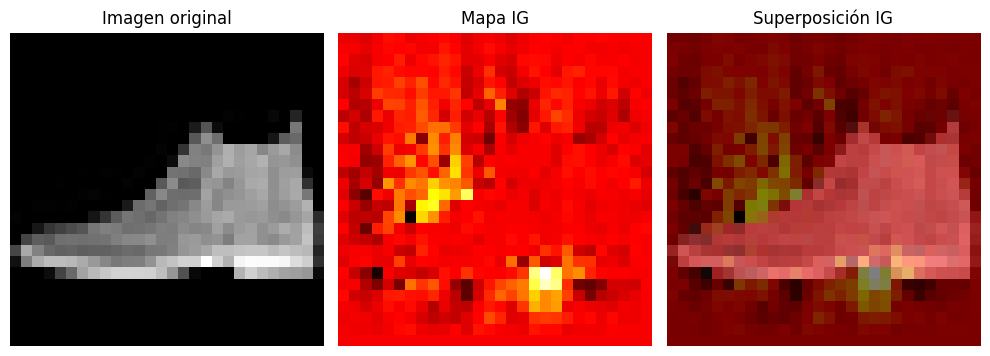

In [87]:
plt.figure(figsize=(10,4))

#Imagen original
plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

# Mapa de contribuciones IG
plt.subplot(1,3,2)
plt.imshow(attr, cmap="hot")
plt.title("Mapa IG")
plt.axis("off")

# Superposición IG + imagen original
plt.subplot(1,3,3)
plt.imshow(img, cmap="gray")
plt.imshow(attr, cmap="hot", alpha=0.5)
plt.title("Superposición IG")
plt.axis("off")

plt.tight_layout()
plt.show()


### Conclusión 

**Imagen original**

Es la entrada real del modelo: un zapato (Sneaker o Ankle Boot).

**Mapa IG (Integrated Gradients)**

Aquí aparecen zonas en rojo/amarillo.
Esas zonas representan los píxeles que más contribuyeron a la predicción del modelo. El modelo se fija sobre todo en:

la punta del zapato,

la suela,

el contorno superior.

Estas son las partes más distintivas para diferenciar un zapato de otras clases de Fashion‑MNIST.

**Superposición IG**

Es la combinación de la imagen original + el mapa IG.

Sirve para ver exactamente dónde “mira” el modelo cuando toma su decisión.

Integrated Gradients permite identificar qué píxeles de la imagen contribuyen de forma más relevante a la predicción del modelo. En el caso de Fashion‑MNIST, el método resalta principalmente los bordes y contornos del objeto, especialmente la punta, la suela y la parte superior del zapato. Estas regiones presentan los mayores cambios de intensidad y son las características más discriminativas para la red neuronal.
La superposición del mapa IG con la imagen original confirma que el modelo basa su decisión en zonas coherentes con la forma real del objeto, lo que indica que la red está aprendiendo patrones visuales razonables y no depende de ruido o artefactos irrelevantes. En resumen, Integrated Gradients proporciona una explicación estable, detallada y alineada con la estructura del objeto, validando el comportamiento interno del modelo.

# GRADCAM

In [26]:
!pip install grad-cam


  Using cached grad_cam-1.5.5-py3-none-any.whl
  Using cached ttach-0.0.3-py3-none-any.whl.metadata (5.2 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
Using cached ttach-0.0.3-py3-none-any.whl (9.8 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [grad-cam]━━ 3/4 [grad-cam]thon]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following

### Importación de librerías

In [88]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# Grad-CAM y utilidades de visualización
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image



###  Tomar una imagen del testloader2

In [89]:
# Tomamos un batch del conjunto de test
dataiter = iter(testloader2)
images, labels = next(dataiter)
# Seleccionamos la primera imagen del batch
input_tensor = images[0].unsqueeze(0)   # (1,1,28,28)
# Guardamos la etiqueta real
label = labels[0].item()

# Convertimos la imagen a numpy y normalizamos entre 0 y 1
img_np = images[0].numpy().transpose(1,2,0)
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())


### Grad-CAM con CONV2

In [90]:
# Creamos el objeto Grad-CAM
cam_conv2 = GradCAM(model=model2, target_layers=[model2.conv2])
grayscale_cam2 = cam_conv2(input_tensor=input_tensor)[0]
# Creamos la superposición del mapa Grad-CAM sobre la imagen original
vis2 = show_cam_on_image(img_np, grayscale_cam2, use_rgb=True)

[W414 12:17:30.841523037 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:30.843620046 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:30.848099475 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:30.849219980 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


### Grad-CAM con CONV3

In [91]:
cam_conv3 = GradCAM(model=model2, target_layers=[model2.conv3])
grayscale_cam3 = cam_conv3(input_tensor=input_tensor)[0]
# Creamos la superposición del mapa Grad-CAM sobre la imagen original
vis3 = show_cam_on_image(img_np, grayscale_cam3, use_rgb=True)

[W414 12:17:33.339480534 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:33.340317726 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:33.343919909 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W414 12:17:33.345197062 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


### Visualización final

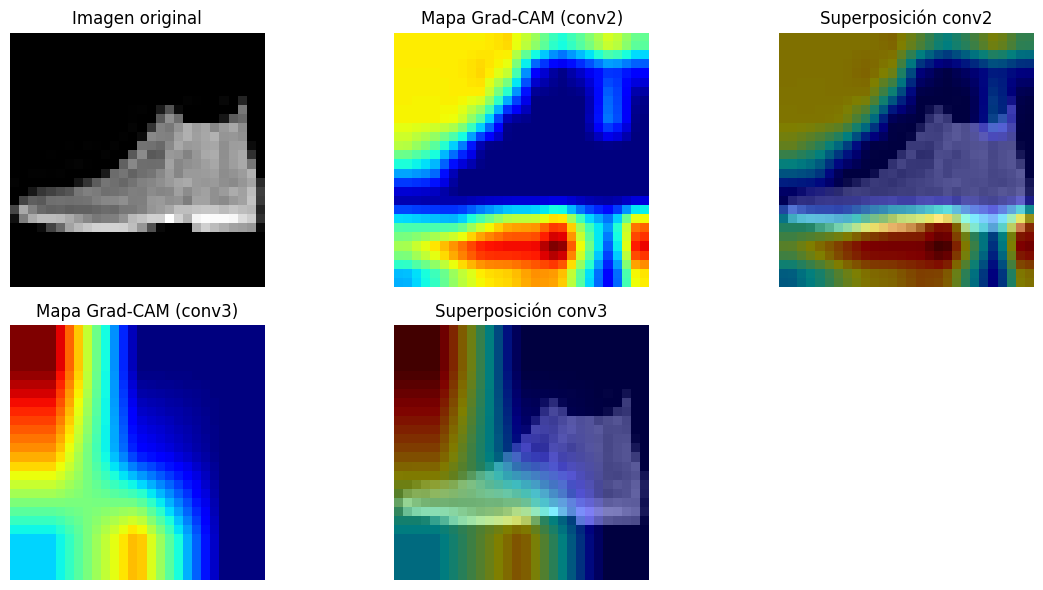

In [92]:
plt.figure(figsize=(12,6))

# Imagen original
plt.subplot(2,3,1)
plt.imshow(img_np.squeeze(), cmap="gray")
plt.title("Imagen original")
plt.axis("off")

# Mapa conv2
plt.subplot(2,3,2)
plt.imshow(grayscale_cam2, cmap="jet")
plt.title("Mapa Grad-CAM (conv2)")
plt.axis("off")

# Superposición conv2
plt.subplot(2,3,3)
plt.imshow(vis2)
plt.title("Superposición conv2")
plt.axis("off")

# Mapa conv3
plt.subplot(2,3,4)
plt.imshow(grayscale_cam3, cmap="jet")
plt.title("Mapa Grad-CAM (conv3)")
plt.axis("off")

# Superposición conv3
plt.subplot(2,3,5)
plt.imshow(vis3)
plt.title("Superposición conv3")
plt.axis("off")

plt.tight_layout()
plt.show()


### Conclusiones

**Conv2 (capa intermedia)**

-El mapa conv2 es más difuso.

-Se activan zonas más amplias.

-El modelo detecta formas parciales, bordes y contornos generales.

-La superposición conv2 muestra activaciones más “extendidas”.

**Conv3 (última convolución)**

-El mapa conv3 es más preciso.

-Se activan zonas más pequeñas y específicas.

-El modelo detecta características de alto nivel, como la forma completa del zapato.

-La superposición conv3 muestra activaciones más enfocadas en la punta, suela y borde superior.

Esto es normal porque conv2 está en un nivel intermedio de abstracción.
Al aplicar Grad‑CAM sobre distintas capas convolucionales del modelo, se observa que las visualizaciones cambian según el nivel de abstracción de cada capa. La capa conv2 produce mapas más difusos y amplios, ya que captura características intermedias como contornos y formas parciales. En cambio, la capa conv3 genera mapas más precisos y focalizados, al contener características de alto nivel directamente relacionadas con la predicción final. Por ello, conv3 es la capa más adecuada para obtener explicaciones claras y coherentes mediante Grad‑CAM.

# LIME

In [93]:
from lime import lime_image
from skimage.segmentation import slic
import numpy as np
import torch

# Función predictora para LIME
def predict_proba(images_np):
    model2.eval()  #Modo evaluación

    # Si vienen en RGB (28,28,3), convertir a 1 canal
    if images_np.shape[-1] == 3:
        images_np = images_np.mean(axis=3, keepdims=True)

    # Convertir a tensor PyTorch (N,1,28,28)
    images_t = torch.tensor(images_np).permute(0,3,1,2).float()

    #Pasamos por el modelo
    with torch.no_grad():
        outputs = model2(images_t)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

    return probs


### Crear el explicador LIME

In [94]:
explainer_lime = lime_image.LimeImageExplainer()


### Tomar una imagen del testloader2

In [95]:
# Tomamos un batch del testloader2
dataiter = iter(testloader2)
images, labels = next(dataiter)

# Imagen en escala de grises (28x28)
img_gray = images[0].numpy().transpose(1,2,0)  # (28,28,1)

# Convertir a RGB duplicando canales (LIME lo necesita)
# LIME necesita 3 canales → duplicamos la imagen
img_rgb = np.repeat(img_gray, 3, axis=2)  # (28,28,3)


### Ejecutar LIME

In [99]:
explanation = explainer_lime.explain_instance(
    img_rgb,            # Imagen en RGB
    predict_proba,      # Función predictora
    top_labels=1,       # Solo explicamos la clase predicha
    hide_color=0,       # Color para ocultar superpixeles
    num_samples=1000,   # Número de perturbaciones (más = más preciso)
    segmentation_fn=lambda x: slic(x, n_segments=100, compactness=1)
)


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1113.10it/s]


### Obtener la máscara y la imagen explicada

In [104]:
# Obtenemos la máscara de superpixeles importantes
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],  # Clase explicada
    positive_only=False,         # Solo superpixeles que ayudan a la predicción
    num_features=5,             # Número de regiones a mostrar
    hide_rest=False              # Ocultar lo que no es importante
)

### Visualización

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


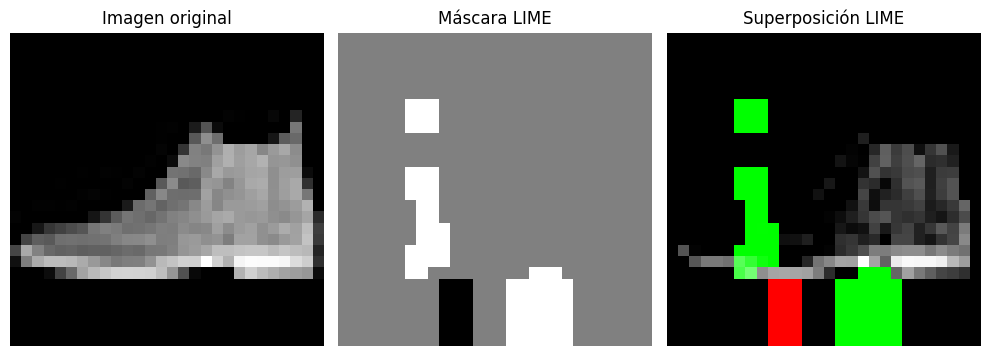

In [105]:
plt.figure(figsize=(10,4))

# Imagen original
plt.subplot(1,3,1)
plt.imshow(img_gray.squeeze(), cmap="gray")
plt.title("Imagen original")
plt.axis("off")

# Máscara LIME
plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara LIME")
plt.axis("off")

# Superposición LIME
plt.subplot(1,3,3)
plt.imshow(temp)
plt.title("Superposición LIME")
plt.axis("off")

plt.tight_layout()
plt.show()



### Conclusion

LIME funciona pintando solo los superpixeles relevantes

-El resto de la imagen lo deja oscuro o negro

-Los colores verde(aumentan probabilidad de clase)/rojo(disminuyen probabilidad)representan regiones que ayudan o perjudican la predicción

-Fashion‑MNIST es muy pequeño (28×28) → hay muy poca información para resaltar

LIME trabaja con superpixeles no con pixeles individuales , en una imagen 28x28 cada superpixel es enorme, el modelo usa muy pocas regiones para clasificar.

LIME identifica las regiones de la imagen que más influyen en la predicción del modelo mediante la perturbación de superpixeles. En Fashion‑MNIST, debido al reducido tamaño de las imágenes (28×28), los superpixeles abarcan áreas relativamente grandes, por lo que solo unas pocas regiones resultan relevantes. En el resultado obtenido, LIME resalta únicamente una pequeña zona del zapato, lo que indica que el modelo basa su decisión en un conjunto muy limitado de características visuales. La superposición muestra claramente qué partes de la imagen contribuyen positiva o negativamente a la clasificación, confirmando que el modelo utiliza patrones coherentes con la forma del objeto. Aunque la visualización es menos detallada que otros métodos como Grad‑CAM o Integrated Gradients, LIME ofrece una explicación local útil y complementaria.

## Analiza, compara y discute los resultados obtenidos.

### Análisis individual de cada método
**Grad‑CAM**
-Resalta zonas amplias y coherentes del zapato.

-En conv2 muestra regiones más difusas (características intermedias).

-En conv3 muestra regiones más precisas (características de alto nivel).

-Identifica correctamente la punta, suela y contorno superior como zonas clave.

-Es muy intuitivo y fácil de interpretar visualmente.

**Integrated Gradients (IG)**
-Produce un mapa más fino y detallado, basado en la contribución de cada píxel.

-Resalta bordes y contornos del zapato con precisión.

-La superposición muestra claramente qué píxeles influyen más en la predicción.

-Es más estable matemáticamente que LIME y más granular que Grad‑CAM.

**LIME**
-Divide la imagen en superpixeles y analiza su importancia.

-En Fashion‑MNIST (28×28), los superpixeles son grandes → pocas regiones relevantes.

-La máscara muestra solo 1–3 zonas importantes.

-La superposición resalta parches verdes/rojos que ayudan o perjudican la predicción.

-Es útil, pero menos detallado debido al tamaño reducido de la imagen.

## Comparación de métodos de explicabilidad: Grad-CAM, Integrated Gradients y LIME

| Método | Tipo de explicación | Precisión espacial | Interpretabilidad | Ventajas | Limitaciones |
|--------|----------------------|--------------------|------------------|----------|--------------|
| **Grad-CAM** | Basado en activaciones de la última capa convolucional | Media | Muy alta | Visualmente intuitivo, muestra regiones amplias relevantes | Depende de la capa seleccionada, menos preciso a nivel de píxel |
| **Integrated Gradients (IG)** | Basado en gradientes acumulados por píxel | Alta | Alta | Explicación fina y detallada, matemáticamente estable | Puede ser ruidoso si no se normaliza bien |
| **LIME** | Basado en perturbación de superpixeles | Baja en imágenes pequeñas | Media | Explicación local, identifica regiones que ayudan o perjudican | Superpixeles muy grandes en 28×28, menos detallado |

## Discusión General
Los tres métodos coinciden en que el modelo CNN2 se basa principalmente en:

-la punta del zapato,

-la suela,

-el contorno superior,

-y los bordes del objeto.

Esto indica que el modelo está aprendiendo características visuales coherentes con la forma real del zapato, lo cual valida su comportamiento interno.

Sin embargo, cada método aporta una perspectiva distinta:

**Grad‑CAM** muestra dónde mira el modelo a nivel de regiones amplias.

**IG** muestra qué píxeles contribuyen más a la predicción.

**LIME** muestra qué superpixeles son relevantes, pero su resolución es limitada en Fashion‑MNIST.

En conjunto, los tres métodos permiten confirmar que:

El modelo no depende de ruido ni artefactos externos.

Las regiones importantes son consistentes entre métodos.

La arquitectura CNN2 está aprendiendo patrones visuales razonables.

LIME es menos detallado debido al tamaño reducido de la imagen, pero sigue siendo útil como explicación local.

La combinación de Grad‑CAM, Integrated Gradients y LIME proporciona una visión completa del proceso de decisión del modelo. Grad‑CAM ofrece una explicación visual intuitiva basada en activaciones profundas; IG aporta una explicación precisa a nivel de píxel; y LIME complementa el análisis mediante perturbaciones locales. Aunque LIME es menos detallado en imágenes pequeñas, los tres métodos coinciden en resaltar las mismas regiones clave del zapato, lo que confirma que el modelo CNN2 toma decisiones basadas en características visuales relevantes y coherentes.
